# Diagnóstico del modelo final: sobreajuste, sesgo y robustez

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

El modelo final para la competencia es **dos etapas + NB-LR robusto** (Mejora 9): el modelo en dos etapas de la Mejora 7 con aumento de datos y con la última oración con opinión. Tiene una exactitud de 0,9081 en la comparación de 15 particiones y 0,91777 en el puntaje público de Kaggle.

Una primera versión de este diagnóstico se hizo con el modelo de la Mejora 7 y encontró su principal debilidad: una frase sin opinión al final de la reseña bastaba para que la exactitud cayera de 0,90 a entre 0,63 y 0,71. La Mejora 9 se diseñó para corregir eso. Esta versión repite todas las revisiones con el modelo final:

1. **Sobreajuste:** si aprende patrones que se generalizan o si memoriza el conjunto de entrenamiento.
2. **Fugas de información:** si el aumento de datos o el detector de opinión, que usan las etiquetas al entrenarse, filtran información de las reseñas de validación (prueba de permutación, nueva en esta versión).
3. **Sesgo entre clases:** si favorece alguna etiqueta y si sus probabilidades son confiables.
4. **Sesgo por tipo de reseña:** si rinde parejo en reseñas con y sin tildes, cortas y largas, y según su estructura.
5. **Robustez:** cómo cambia su desempeño ante cambios realistas del texto que podrían aparecer en datos reales.
6. **Parecido entre los datos de la competencia y los de entrenamiento:** de eso depende que el puntaje final se parezca al de la validación cruzada.

Como referencia simple, todo se compara con la regresión logística robusta de la Mejora 9, que tiene los mismos dos arreglos.

Este notebook no entrena un modelo nuevo ni genera envíos para Kaggle.

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']
RUTA_DATOS = os.path.join('..', 'data')
RUTA_ENVIOS = os.path.join('..', 'submissions')

## 2. Datos

Para tener la mayor cantidad posible de predicciones que analizar, se usa validación cruzada de 5 particiones sobre las 12.000 reseñas etiquetadas: cada reseña recibe una predicción de un modelo que no la vio al entrenarse. Así todos los análisis se hacen con 12.000 predicciones fuera de muestra, en vez de las 2.400 de un solo conjunto de prueba.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
X = train[['text']]
y = train['label']

# Validación cruzada de 5 particiones sobre las 12.000 reseñas: cada reseña recibe una predicción
# de un modelo que no la vio al entrenarse (predicción "fuera de muestra")
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
particiones = list(kfold.split(X, y))
print('train:', train.shape, '| eval:', evaluacion.shape)

train: (12000, 3) | eval: (3000, 2)


## 3. Modelos que se revisan

Las celdas siguientes copian sin cambios el código del notebook de la Mejora 9: el preprocesamiento, la corrección de la cláusula final, NB-LR y la clase `ModeloDosEtapasNBLR` (que vienen de la Mejora 7), el aumento de datos (`ConAumento`) y el detector de opinión (`ExtraerConOpinion` y `ModeloDosEtapasNBLROpinion`). Se revisan dos modelos:

- **Dos etapas + NB-LR robusto (Mejora 9):** el modelo final, con `C_etapa2 = 0,1`, aumento de datos en la mitad de las reseñas y la última oración con opinión.
- **Regresión logística robusta (Mejora 9):** la regresión logística L1 (`C = 10`) sobre los tres bloques de TF-IDF, con los mismos dos arreglos. Es el modelo más simple de los buenos y sirve para saber si un problema es del modelo complejo o de los datos.

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [6]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]

In [7]:
class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [8]:
def aumentar(textos, etiquetas, proporcion=0.5, semilla=0):
    """Agrega al final de una proporción de las reseñas una oración tomada de reseñas neutrales (sin cambiar la etiqueta)."""
    rng = np.random.default_rng(semilla)
    banco = [o for t, e in zip(textos, etiquetas) if e == 'neutral' for o in separar_oraciones(t) if len(o.split()) >= 4]
    return [t.rstrip() + ' ' + banco[rng.integers(len(banco))] if rng.random() < proporcion else t for t in textos]


class ConAumento(ClassifierMixin, BaseEstimator):
    """Entrena el modelo con el arreglo A aplicado solo a los datos de entrenamiento. Al predecir no cambia nada."""

    def __init__(self, modelo, proporcion=0.5, random_state=0):
        self.modelo = modelo
        self.proporcion = proporcion
        self.random_state = random_state

    def fit(self, X, y):
        textos = aumentar(list(X['text']), np.asarray(y), self.proporcion, self.random_state)
        self.modelo_ = clone(self.modelo).fit(pd.DataFrame({'text': textos}), np.asarray(y))
        self.classes_ = self.modelo_.classes_
        return self

    def predict_proba(self, X):
        return self.modelo_.predict_proba(X)

    def predict(self, X):
        return self.modelo_.predict(X)

In [9]:
class ExtraerConOpinion(BaseEstimator, TransformerMixin):
    """Devuelve, limpia, la última oración con opinión de cada reseña (o su cláusula final).

    Un detector distingue "opinión" de "hecho": una regresión logística sobre TF-IDF entrenada con las oraciones de
    reseñas neutrales (hecho) y con la cláusula final de las reseñas positivas o negativas (casi siempre una opinión).
    Una oración tiene opinión si P(opinión) > umbral. Si ninguna la tiene, se usa la última oración.
    Para las oraciones de entrenamiento se usa la probabilidad fuera de muestra (validación cruzada agrupada por
    reseña); si no, el detector las reconocería de memoria.
    """

    def __init__(self, parte='ultima', umbral=0.5, stemming=True):
        self.parte = parte
        self.umbral = umbral
        self.stemming = stemming

    def fit(self, X, y):
        textos, y = list(np.asarray(X)), np.asarray(y)
        frases, etiquetas, grupo = [], [], []
        for i, (t, e) in enumerate(zip(textos, y)):
            if e == 'neutral':
                for o in separar_oraciones(t):
                    frases.append(limpiar_texto(o)); etiquetas.append(0); grupo.append(i)
            else:
                frases.append(limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]))); etiquetas.append(1); grupo.append(i)
        frases, etiquetas, grupo = np.array(frases, dtype=object), np.array(etiquetas), np.array(grupo)
        self.fuera_de_muestra_ = {}
        for a, b in GroupKFold(n_splits=5).split(frases, etiquetas, grupo):
            vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
            m = LogisticRegression(C=1, max_iter=2000).fit(vec.fit_transform(frases[a]), etiquetas[a])
            for o, p in zip(frases[b], m.predict_proba(vec.transform(frases[b]))[:, 1]):
                self.fuera_de_muestra_[o] = p
        self.vectorizador_ = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
        self.detector_ = LogisticRegression(C=1, max_iter=2000).fit(self.vectorizador_.fit_transform(frases), etiquetas)
        return self

    def prob_opinion(self, oraciones_limpias):
        faltan = [o for o in oraciones_limpias if o not in self.fuera_de_muestra_]
        nuevas = dict(zip(faltan, self.detector_.predict_proba(self.vectorizador_.transform(faltan))[:, 1])) if faltan else {}
        return np.array([self.fuera_de_muestra_.get(o, nuevas.get(o)) for o in oraciones_limpias])

    def oracion_con_opinion(self, texto):
        oraciones = separar_oraciones(texto)
        p = self.prob_opinion([limpiar_texto(o) for o in oraciones])
        con_opinion = np.where(p > self.umbral)[0]
        return oraciones[con_opinion[-1]] if len(con_opinion) else oraciones[-1]

    def transform(self, X):
        salida = []
        for t in np.asarray(X):
            o = self.oracion_con_opinion(t)
            if self.parte == 'clausula':
                o = ultimo_fragmento(o)
            salida.append(limpiar_texto(o, stemming=self.stemming))
        return salida


def construir_representacion_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
    ])


def construir_bolsas_binarias_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
    ])


class ModeloDosEtapasNBLROpinion(ModeloDosEtapasNBLR):
    """Mejora 7 con los bloques de última oración y cláusula final tomados de la última oración con opinión."""

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_opinion().fit(datos, etiquetas)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias_opinion()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

In [10]:
modelos = {
    'Dos etapas + NB-LR robusto (Mejora 9)': ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1)),
    'Regresión logística robusta (Mejora 9)': ConAumento(Pipeline([
        ('rep', construir_representacion_opinion()),
        ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)),
    ])),
}
ELEGIDO, SIMPLE = list(modelos)

## 4. Predicciones fuera de muestra

`cross_validate` entrena cada modelo en las 5 particiones y devuelve los modelos entrenados (`return_estimator=True`) y la exactitud en entrenamiento (`return_train_score=True`). Con esos modelos se obtienen las probabilidades fuera de muestra de cada reseña, que se reutilizan en el resto del notebook.

In [11]:
resultados_cv = {}
prob_oof = {}
for nombre, modelo in modelos.items():
    resultados_cv[nombre] = cross_validate(modelo, X, y, cv=particiones, scoring='accuracy',
                                           return_train_score=True, return_estimator=True, n_jobs=-1)
    P = np.zeros((len(X), 3))
    for estimador, (_, idx_val) in zip(resultados_cv[nombre]['estimator'], particiones):
        P[idx_val] = estimador.predict_proba(X.iloc[idx_val])
    prob_oof[nombre] = P

clases = np.array(sorted(y.unique()))
pred_oof = {nombre: clases[P.argmax(axis=1)] for nombre, P in prob_oof.items()}
acierto = {nombre: pred == y.values for nombre, pred in pred_oof.items()}
for nombre in modelos:
    print(f'{nombre:32s} exactitud fuera de muestra: {acierto[nombre].mean():.4f}')

Dos etapas + NB-LR robusto (Mejora 9) exactitud fuera de muestra: 0.9103
Regresión logística robusta (Mejora 9) exactitud fuera de muestra: 0.9080


## 5. Sobreajuste

### 5.1 Entrenamiento frente a validación

In [12]:
tabla_brecha = pd.DataFrame({
    nombre: {'Exactitud entrenamiento': r['train_score'].mean(),
             'Exactitud validación': r['test_score'].mean(),
             'Diferencia': r['train_score'].mean() - r['test_score'].mean(),
             'Desviación entre particiones (validación)': r['test_score'].std(ddof=1)}
    for nombre, r in resultados_cv.items()}).T
tabla_brecha.round(4)

,Exactitud entrenamiento,Exactitud validación,Diferencia,Desviación entre particiones (validación)
Dos etapas + NB-LR robusto (Mejora 9),0.9840,0.9103,0.0738,0.0046
Regresión logística robusta (Mejora 9),0.9938,0.9080,0.0858,0.0037


El modelo final acierta el 98,4% de las reseñas con las que se entrenó y el 91,0% de las que no vio: 7,4 puntos de diferencia. La regresión logística robusta acierta el 99,4% en entrenamiento y el 90,8% fuera de muestra (8,6 puntos). La exactitud de validación es estable entre particiones: la desviación del modelo final es de 0,46 puntos.

En la primera versión de este diagnóstico, el modelo de la Mejora 7 tenía 8,8 puntos de diferencia (99,1% contra 90,3%). El modelo final acierta un poco menos en entrenamiento y más fuera de muestra, así que sobreajusta menos. Es lo esperable del aumento de datos, que agrega variaciones a las reseñas de entrenamiento y hace más difícil memorizarlas. Aun así, una diferencia de 7 puntos suele leerse como sobreajuste, y conviene ver de dónde viene.

### 5.2 ¿De dónde viene la diferencia?

In [13]:
def clave_oracion(oracion):
    return re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).strip()


finales = Counter(clave_oracion(separar_oraciones(t)[-1]) for t in X['text'])
cierres = {o for o, n in finales.items() if n >= 12}
ADITIVOS = ('por otro', 'de paso', 'por cierto', 'ademas')


def tipo_de_resena(texto, etiqueta):
    if etiqueta == 'neutral':
        return 'Neutral'
    if clave_oracion(separar_oraciones(texto)[-1]) in cierres:
        return 'Termina en un cierre ambiguo'
    comienzos = [comienzo_oracion(o) for o in separar_oraciones(texto)[1:]]
    if any(c.startswith(a) for c in comienzos for a in ADITIVOS):
        return 'Conector aditivo'
    if re.search(r'\b(pero|aunque|aun asi|con todo|al final|eso si|ahora|en cambio)\b', quitar_tildes(texto.lower())):
        return 'Conector adversativo'
    return 'Sin conector de contraste'


tipo = pd.Series([tipo_de_resena(t, e) for t, e in zip(X['text'], y)], index=y.index)
tipo.value_counts()

Conector adversativo            3717
Neutral                         3576
Sin conector de contraste       2561
Conector aditivo                1212
Termina en un cierre ambiguo     934
Name: count, dtype: int64

In [14]:
# Exactitud en entrenamiento: el modelo de la primera partición, evaluado sobre las reseñas con que se entrenó
idx_ent, _ = particiones[0]
modelo_1 = resultados_cv[ELEGIDO]['estimator'][0]
acierto_ent = pd.Series(modelo_1.predict(X.iloc[idx_ent]) == y.values[idx_ent], index=y.index[idx_ent])

brecha_grupos = pd.DataFrame({
    'reseñas': tipo.value_counts(),
    'exactitud entrenamiento': acierto_ent.groupby(tipo[idx_ent]).mean(),
    'exactitud fuera de muestra': pd.Series(acierto[ELEGIDO], index=y.index).groupby(tipo).mean(),
})
brecha_grupos['diferencia'] = brecha_grupos['exactitud entrenamiento'] - brecha_grupos['exactitud fuera de muestra']
brecha_grupos.sort_values('diferencia', ascending=False).round(3)

,reseñas,exactitud entrenamiento,exactitud fuera de muestra,diferencia
Termina en un cierre ambiguo,934,0.933,0.536,0.397
Conector aditivo,1212,0.951,0.815,0.135
Conector adversativo,3717,0.987,0.930,0.057
Sin conector de contraste,2561,0.986,0.939,0.047
Neutral,3576,1.000,0.999,0.001


Casi toda la diferencia está en las reseñas ambiguas. En las que terminan en un cierre ambiguo, el modelo acierta el 93,3% de las que vio en entrenamiento y solo el 53,6% de las que no vio: aprende de memoria etiquetas que parecen azarosas. En las de conector aditivo la diferencia es de 13,5 puntos, en las de una opinión clara de unos 5 puntos y en las neutrales prácticamente cero.

Es decir, el sobreajuste consiste sobre todo en memorizar las reseñas ambiguas del entrenamiento. Eso no parece afectar el desempeño en reseñas nuevas, porque en esas reseñas ningún modelo supera mucho al azar. Pero explica por qué la exactitud de entrenamiento no es un buen indicador del desempeño real.

### 5.3 Curva de aprendizaje

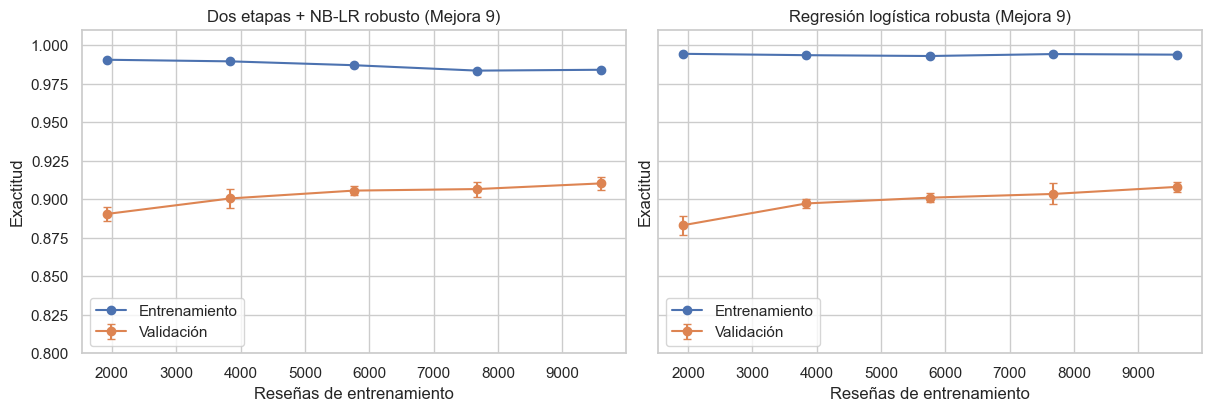

Dos etapas + NB-LR robusto (Mejora 9)


,reseñas de entrenamiento,entrenamiento,validación,desv. validación
0,1920,0.9905,0.8904,0.0042
1,3840,0.9895,0.9005,0.0060
2,5760,0.9870,0.9056,0.0028
3,7680,0.9835,0.9066,0.0049
4,9600,0.9840,0.9103,0.0042


Regresión logística robusta (Mejora 9)


,reseñas de entrenamiento,entrenamiento,validación,desv. validación
0,1920,0.9944,0.8831,0.0061
1,3840,0.9935,0.8972,0.0030
2,5760,0.9930,0.9010,0.0027
3,7680,0.9942,0.9034,0.0068
4,9600,0.9938,0.9080,0.0033


In [15]:
tamanos = [0.2, 0.4, 0.6, 0.8, 1.0]
curvas = {}
for nombre, modelo in modelos.items():
    n, ent, val = learning_curve(modelo, X, y, train_sizes=tamanos, cv=particiones, scoring='accuracy', n_jobs=-1)
    curvas[nombre] = pd.DataFrame({'reseñas de entrenamiento': n, 'entrenamiento': ent.mean(axis=1),
                                   'validación': val.mean(axis=1), 'desv. validación': val.std(axis=1)})

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True, sharey=True)
for eje, (nombre, curva) in zip(ax, curvas.items()):
    eje.plot(curva['reseñas de entrenamiento'], curva['entrenamiento'], marker='o', label='Entrenamiento')
    eje.errorbar(curva['reseñas de entrenamiento'], curva['validación'], yerr=curva['desv. validación'],
                 marker='o', capsize=3, label='Validación')
    eje.set(title=nombre, xlabel='Reseñas de entrenamiento', ylabel='Exactitud', ylim=(0.80, 1.01))
    eje.legend()
plt.show()

for nombre, curva in curvas.items():
    print(nombre)
    display(curva.round(4))

La exactitud de validación del modelo final sube de 0,890 con 1.920 reseñas a 0,910 con 9.600, y todavía no se estabiliza: entre 7.680 y 9.600 reseñas sube 0,37 puntos. La de entrenamiento baja levemente (de 0,991 a 0,984), como es normal cuando el modelo tiene que ajustarse a más ejemplos, y la diferencia entre las dos curvas se reduce de 10,0 a 7,4 puntos. Más datos del mismo tipo ayudarían algo, del orden de décimas de punto, sin cerrar la brecha, porque buena parte de ella son las reseñas ambiguas. La regresión logística robusta se comporta igual, entre 0,2 y 0,7 puntos por debajo y con la exactitud de entrenamiento siempre cerca del 99,4%.

### 5.4 Prueba de permutación: ¿hay fugas de información?

La Mejora 9 agrega dos piezas que usan las etiquetas al entrenarse: el aumento de datos, que toma oraciones de las reseñas neutrales, y el detector de opinión, que aprende de las oraciones de cada clase. Si alguna de ellas usara por error información de las reseñas de validación, la validación cruzada daría una exactitud demasiado optimista.

Para comprobarlo se barajan las etiquetas al azar y se repite la validación cruzada. Así ya no hay ninguna relación entre el texto y la etiqueta, y un modelo sin fugas no puede superar el azar: su exactitud de validación debería quedar alrededor de la proporción de la clase más frecuente. Si quedara claramente por encima, habría una fuga.

In [16]:
# Se barajan las etiquetas al azar: ya no hay ninguna relación entre el texto y la etiqueta
y_barajada = pd.Series(y.sample(frac=1, random_state=0).values, index=y.index)
filas = {}
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X, y_barajada, cv=particiones, scoring='accuracy', return_train_score=True, n_jobs=-1)
    filas[nombre] = {'Exactitud entrenamiento': r['train_score'].mean(), 'Exactitud validación': r['test_score'].mean(),
                     'Desviación validación': r['test_score'].std(ddof=1)}
display(pd.DataFrame(filas).T.round(4))
print(f'Proporción de la clase más frecuente: {y_barajada.value_counts(normalize=True).max():.4f}')

,Exactitud entrenamiento,Exactitud validación,Desviación validación
Dos etapas + NB-LR robusto (Mejora 9),0.3646,0.3517,0.0116
Regresión logística robusta (Mejora 9),0.8476,0.3278,0.0118


Proporción de la clase más frecuente: 0.3510


No hay fugas de información. Con las etiquetas barajadas, el modelo final queda en 0,352 de exactitud de validación, igual que la proporción de la clase más frecuente (0,351). La regresión logística robusta queda en 0,328, también al nivel del azar: como reparte sus predicciones entre las tres clases, acierta un poco menos que si predijera siempre la más frecuente. Si el aumento de datos o el detector filtraran etiquetas de validación, la exactitud quedaría por encima de esos valores.

La prueba muestra algo más. Con etiquetas al azar, la regresión logística llega a acertar el 84,8% de las reseñas de entrenamiento, aunque no haya nada que aprender. Es decir, tiene capacidad para memorizar casi cualquier cosa, y por eso su exactitud de entrenamiento con las etiquetas reales (99,4%) no dice mucho sobre su desempeño real. El modelo en dos etapas, en cambio, se queda en 36,5%: su etapa 2 se entrena con predicciones fuera de muestra y con una regularización fuerte (`C_etapa2 = 0,1`), así que no puede memorizar etiquetas sin relación con el texto.

### 5.5 ¿Coincide la validación cruzada con Kaggle?

In [17]:
# Comparación con 15 particiones (notebook de la Mejora 9) y puntaje público de Kaggle del modelo final
exactitud_15 = 0.9081
aciertos_publico, n_publico = 826, 900
n_privado = 3000 - n_publico

error_publico = np.sqrt(exactitud_15 * (1 - exactitud_15) / n_publico)
error_privado = np.sqrt(exactitud_15 * (1 - exactitud_15) / n_privado)
print(f'Puntaje público: {aciertos_publico / n_publico:.4f} ({aciertos_publico} de {n_publico})')
print(f'Lo esperado según la validación cruzada: {exactitud_15:.4f} +/- {1.96 * error_publico:.4f} (95%, con {n_publico} reseñas)')
print(f'Diferencia: {aciertos_publico / n_publico - exactitud_15:+.4f}, es decir, {(aciertos_publico / n_publico - exactitud_15) / error_publico:.1f} errores estándar')
print(f'\nRango esperado para el puntaje final ({n_privado} reseñas): '
      f'{exactitud_15 - 1.96 * error_privado:.4f} a {exactitud_15 + 1.96 * error_privado:.4f} (95%)')

Puntaje público: 0.9178 (826 de 900)
Lo esperado según la validación cruzada: 0.9081 +/- 0.0189 (95%, con 900 reseñas)
Diferencia: +0.0097, es decir, 1.0 errores estándar

Rango esperado para el puntaje final (2100 reseñas): 0.8957 a 0.9205 (95%)


El puntaje público (0,9178) está 0,97 puntos por encima de la exactitud en la comparación de 15 particiones (0,9081), 1,0 errores estándar: es compatible. El modelo se eligió con las 15 particiones, antes de conocer su puntaje público, así que el puntaje público funciona como una prueba independiente. Si el modelo estuviera sobreajustado, quedaría por debajo de la validación, no por encima.

Lo más probable es que el puntaje público haya salido algo favorecido por el azar. Para el puntaje final, que normalmente se calcula con las 2.100 reseñas restantes, se espera una exactitud de entre 0,896 y 0,921 (intervalo del 95%), centrada en la de la validación cruzada.

## 6. Sesgo entre clases y confianza de las probabilidades

### 6.1 ¿Favorece alguna clase?

,% negativo,% neutral,% positivo
Real,35.1,29.8,35.1
Dos etapas + NB-LR robusto (Mejora 9),35.2,29.8,34.9
Regresión logística robusta (Mejora 9),34.6,29.8,35.6


,negativo → positivo,positivo → negativo,errores con neutral,sensibilidad negativo,sensibilidad neutral,sensibilidad positivo
Dos etapas + NB-LR robusto (Mejora 9),524.0,543.0,10.0,0.875,0.999,0.870
Regresión logística robusta (Mejora 9),564.0,505.0,35.0,0.864,0.995,0.878


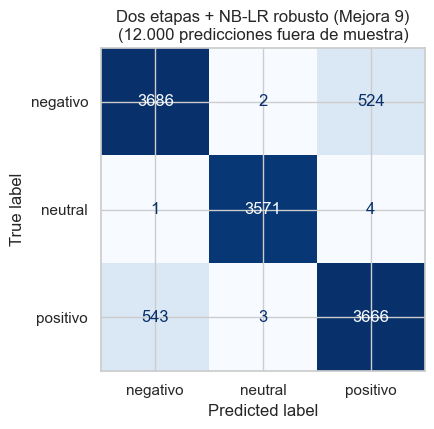

In [18]:
filas = {'Real': y.value_counts(normalize=True).reindex(ORDEN_CLASES)}
for nombre, pred in pred_oof.items():
    filas[nombre] = pd.Series(pred).value_counts(normalize=True).reindex(ORDEN_CLASES)
display((pd.DataFrame(filas).T * 100).round(1).rename(columns=lambda c: f'% {c}'))

resumen = {}
for nombre, pred in pred_oof.items():
    resumen[nombre] = {
        'negativo → positivo': int(((y == 'negativo') & (pred == 'positivo')).sum()),
        'positivo → negativo': int(((y == 'positivo') & (pred == 'negativo')).sum()),
        'errores con neutral': int((((y == 'neutral') | (pred == 'neutral')) & (y != pred)).sum()),
        **{f'sensibilidad {c}': ((pred == c) & (y == c)).sum() / (y == c).sum() for c in ORDEN_CLASES},
    }
display(pd.DataFrame(resumen).T.round(3))

fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay.from_predictions(y, pred_oof[ELEGIDO], labels=ORDEN_CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'{ELEGIDO}\n(12.000 predicciones fuera de muestra)')
plt.show()

El modelo final no favorece ninguna clase. Predice 35,2% de negativos, 29,8% de neutrales y 34,9% de positivos, casi idéntico a la distribución real (35,1%, 29,8% y 35,1%). Confunde negativos con positivos (524) y positivos con negativos (543) en cantidades parecidas, y su sensibilidad es casi la misma en las dos clases (0,875 y 0,870). Con `neutral` casi no se equivoca: 10 errores en 12.000 reseñas.

La regresión logística robusta tiene una leve inclinación hacia `positivo` (564 contra 505 confusiones) y comete más errores relacionados con `neutral` (35). El modelo en dos etapas corrige ese sesgo.

### 6.2 ¿Son confiables sus probabilidades?

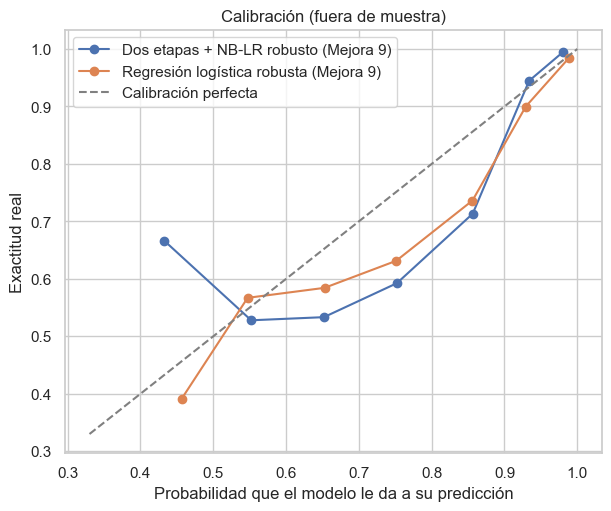

Dos etapas + NB-LR robusto (Mejora 9)


,reseñas,confianza_media,exactitud
rango,,,
"(0.329, 0.5]",3,0.432,0.667
"(0.5, 0.6]",502,0.552,0.528
"(0.6, 0.7]",495,0.652,0.533
"(0.7, 0.8]",530,0.752,0.592
"(0.8, 0.9]",771,0.856,0.713
"(0.9, 0.95]",2314,0.934,0.945
"(0.95, 1.0]",7385,0.980,0.994


Regresión logística robusta (Mejora 9)


,reseñas,confianza_media,exactitud
rango,,,
"(0.329, 0.5]",23,0.457,0.391
"(0.5, 0.6]",575,0.547,0.567
"(0.6, 0.7]",498,0.653,0.584
"(0.7, 0.8]",548,0.751,0.631
"(0.8, 0.9]",804,0.856,0.736
"(0.9, 0.95]",889,0.929,0.900
"(0.95, 1.0]",8663,0.989,0.985


In [19]:
cortes = [0.33, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
tablas = {}
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
for nombre, P in prob_oof.items():
    confianza = P.max(axis=1)
    rango = pd.cut(confianza, cortes, include_lowest=True)
    tabla = pd.DataFrame({'confianza': confianza, 'acierto': acierto[nombre], 'rango': rango}).groupby('rango', observed=True).agg(
        reseñas=('acierto', 'size'), confianza_media=('confianza', 'mean'), exactitud=('acierto', 'mean'))
    tablas[nombre] = tabla
    ax.plot(tabla['confianza_media'], tabla['exactitud'], marker='o', label=nombre)
ax.plot([0.33, 1], [0.33, 1], linestyle='--', color='gray', label='Calibración perfecta')
ax.set(xlabel='Probabilidad que el modelo le da a su predicción', ylabel='Exactitud real', title='Calibración (fuera de muestra)')
ax.legend()
plt.show()

for nombre, tabla in tablas.items():
    print(nombre)
    display(tabla.round(3))

Cuando el modelo está muy seguro, acierta. Las 7.385 reseñas a las que les da más de 0,95 de probabilidad tienen 99,4% de exactitud, y las 2.314 entre 0,90 y 0,95 tienen 94,5%. En cambio, en el rango intermedio es demasiado optimista: cuando su confianza media es 0,86 acierta el 71,3%, cuando es 0,75 el 59,2%, y entre 0,5 y 0,7 acierta poco más de la mitad de las veces. Esas reseñas son, en su mayoría, las ambiguas.

En términos prácticos, el 19% de las reseñas en las que su confianza es de 0,9 o menos concentra el 84% de sus errores. La regresión logística robusta está algo mejor calibrada en el rango intermedio (acierta el 73,6% cuando su confianza es 0,86), pero exagera un poco en el rango alto.

Para la competencia esto no importa, porque solo se usa la clase más probable. Si el modelo se usara para tomar decisiones con sus probabilidades, por ejemplo para revisar a mano las reseñas dudosas, convendría calibrarlas antes.

## 7. ¿Rinde parejo en distintos tipos de reseña?

In [20]:
palabras = X['text'].str.split().str.len()
n_oraciones = X['text'].map(lambda t: len(separar_oraciones(t)))
sin_marcas = ~X['text'].str.contains('[áéíóúüñ¿¡]')

definiciones = {
    'Tildes': np.where(sin_marcas, 'sin tildes ni ñ', 'con tildes'),
    'Longitud': pd.qcut(palabras, 3, labels=['corta (tercio inferior)', 'media', 'larga (tercio superior)']).astype(str),
    'Oraciones': np.select([n_oraciones <= 3, n_oraciones == 4], ['1 a 3', '4'], '5 o más'),
    'Tipo de reseña': tipo.values,
}
filas = []
for variable, grupo in definiciones.items():
    grupo = pd.Series(grupo, index=y.index)
    for valor in sorted(grupo.unique()):
        m = (grupo == valor).values
        filas.append({'variable': variable, 'grupo': valor, 'reseñas': int(m.sum()),
                      **{nombre: acierto[nombre][m].mean() for nombre in modelos}})
tabla_grupos = pd.DataFrame(filas).set_index(['variable', 'grupo'])
tabla_grupos.round(3)

reseñas  Dos etapas + NB-LR robusto (Mejora 9)  Regresión logística robusta (Mejora 9)
variable       grupo                                                                                                               
Tildes         con tildes                       8244                                  0.911                                   0.908
               sin tildes ni ñ                  3756                                  0.908                                   0.907
Longitud       corta (tercio inferior)          4022                                  0.916                                   0.912
               larga (tercio superior)          3967                                  0.913                                   0.912
               media                            4011                                  0.902                                   0.900
Oraciones      1 a 3                            2862                                  0.959                                   0.952
               4                                7098                                  0.923                                   0.919
               5 o más                          2040                                  0.797                                   0.807
Tipo de reseña Conector aditivo                 1212                                  0.815                                   0.818
               Conector adversativo             3717                                  0.930                                   0.929
               Neutral                          3576                                  0.999                                   0.995
               Sin conector de contraste        2561                                  0.939                                   0.937
               Termina en un cierre ambiguo      934                                  0.536                                   0.530

- **Tildes:** no hay sesgo. El modelo acierta lo mismo en reseñas con tildes (0,911) y sin ellas (0,908), porque el preprocesamiento las quita.
- **Longitud en palabras:** las diferencias son pequeñas (de 0,902 a 0,916).
- **Número de oraciones:** aquí está la diferencia grande. La exactitud es de 0,959 en reseñas de 1 a 3 oraciones, 0,923 con 4 y 0,797 con 5 o más. La razón está en la composición de esos grupos: en las reseñas de 5 o más oraciones, el 25,7% termina en un cierre ambiguo y el 16,4% usa un conector aditivo, contra el 1,6% y el 6,8% en las de 1 a 3 oraciones. La regresión logística tiene el mismo patrón (0,807 con 5 o más), así que es una propiedad de los datos más que del modelo.
- **Tipo de reseña:** se repite lo ya conocido. `neutral` es casi perfecto, los cierres ambiguos quedan cerca del azar (0,536) y el conector aditivo es el grupo difícil restante (0,815).

## 8. Pruebas de robustez

Un modelo puede rendir bien en la competencia y fallar con reseñas reales que se escriben un poco distinto. Para medirlo, a las reseñas de validación de cada partición se les aplica un cambio y se vuelven a predecir con el mismo modelo, sin reentrenarlo:

- **Sin tildes ni ñ:** quitar todas las tildes y la ñ ("diseño" → "diseno").
- **Con errores de digitación:** en el 5% de las palabras de 4 o más letras, duplicar una letra o intercambiar dos letras vecinas.
- **Con una frase neutra al final:** agregar "Lo uso casi todos los días en la oficina." al final de la reseña. Es la prueba más importante, porque es la debilidad que encontró la primera versión de este diagnóstico y que la Mejora 9 intenta corregir.
- **Sin la primera oración:** quitar la primera oración, que suele ser contexto de la compra.

Ninguno de estos cambios debería modificar la etiqueta de la reseña, así que un modelo robusto debería mantener su exactitud.

In [21]:
def sin_tildes_texto(texto):
    return quitar_tildes(texto)


def con_errores(texto, proporcion=0.05, semilla=0):
    # Duplica una letra o intercambia dos letras vecinas en el 5% de las palabras de 4 o más letras
    rng = np.random.default_rng(semilla)
    palabras = texto.split(' ')
    for i, p in enumerate(palabras):
        if len(p) >= 4 and rng.random() < proporcion:
            j = rng.integers(1, len(p) - 1)
            palabras[i] = p[:j] + p[j] + p[j:] if rng.random() < 0.5 else p[:j - 1] + p[j] + p[j - 1] + p[j + 1:]
    return ' '.join(palabras)


def con_frase_neutra(texto):
    return texto.rstrip() + ' Lo uso casi todos los días en la oficina.'


def sin_primera_oracion(texto):
    oraciones = separar_oraciones(texto)
    return ' '.join(oraciones[1:]) if len(oraciones) > 1 else texto


ejemplo = X['text'].iloc[0]
for nombre_p, f in [('sin tildes', sin_tildes_texto), ('con errores', lambda t: con_errores(t, 0.3)),
                    ('con frase neutra al final', con_frase_neutra), ('sin la primera oración', sin_primera_oracion)]:
    print(f'{nombre_p:26s} {f(ejemplo)[:160]}')

sin tildes                 Lo pedi un martes por la noche y me llego al dia siguiente. Es el modelo en color negro, el basico de la linea. Lo pese en la bascula de la cocina y marca algo 
con errores                Lo pedí un marrtes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la ílnea. Lo pessé en la báscula de la cocina y marcca la
con frase neutra al final  Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo 
sin la primera oración     Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el escritorio del trabajo y p


In [22]:
perturbaciones = {
    'Sin tildes ni ñ': sin_tildes_texto,
    'Con errores de digitación (5% de las palabras)': con_errores,
    'Con una frase neutra al final': con_frase_neutra,
    'Sin la primera oración': sin_primera_oracion,
}
filas = []
pred_perturbada = {}
for nombre, r in resultados_cv.items():
    for nombre_p, f in perturbaciones.items():
        aciertos, cambios = [], []
        pred_perturbada[(nombre, nombre_p)] = np.empty(len(X), dtype=object)
        for k, (estimador, (_, idx_val)) in enumerate(zip(r['estimator'], particiones)):
            textos = X.iloc[idx_val]['text']
            if nombre_p.startswith('Con errores'):
                nuevos = [con_errores(t, semilla=i) for i, t in zip(idx_val, textos)]
            else:
                nuevos = [f(t) for t in textos]
            pred = estimador.predict(pd.DataFrame({'text': nuevos}))
            pred_perturbada[(nombre, nombre_p)][idx_val] = pred
            aciertos.append(pred == y.values[idx_val])
            cambios.append(pred != pred_oof[nombre][idx_val])
        exactitud = np.concatenate(aciertos).mean()
        filas.append({'modelo': nombre, 'cambio en el texto': nombre_p, 'exactitud': exactitud,
                      'diferencia vs original': exactitud - acierto[nombre].mean(),
                      'predicciones que cambian': int(np.concatenate(cambios).sum())})
tabla_robustez = pd.DataFrame(filas).set_index(['modelo', 'cambio en el texto'])
tabla_robustez.round(4)

exactitud  diferencia vs original  predicciones que cambian
modelo                                 cambio en el texto                                                                                         
Dos etapas + NB-LR robusto (Mejora 9)  Sin tildes ni ñ                                    0.9102                  0.0000                         0
                                       Con errores de digitación (5% de las palabras)     0.8998                 -0.0105                       292
                                       Con una frase neutra al final                      0.9081                 -0.0022                       258
                                       Sin la primera oración                             0.9098                 -0.0004                       227
Regresión logística robusta (Mejora 9) Sin tildes ni ñ                                    0.9080                  0.0000                         0
                                       Con errores de digitación (5% de las palabras)     0.8970                 -0.0110                       319
                                       Con una frase neutra al final                      0.9050                 -0.0030                       166
                                       Sin la primera oración                             0.9055                 -0.0025                       308

- **Sin tildes ni ñ:** no cambia ninguna predicción, porque el preprocesamiento ya las elimina.
- **Errores de digitación en el 5% de las palabras:** la exactitud baja cerca de 1 punto (de 0,9102 a 0,8998) y cambian 292 predicciones. El modelo depende de que las palabras clave estén bien escritas, así que una palabra mal escrita se pierde. Los arreglos de la Mejora 9 no cambian esto.
- **Sin la primera oración:** casi no afecta (−0,04 puntos). El contexto inicial casi no aporta, como se vio en el notebook principal.
- **Con una frase neutra al final:** la debilidad está corregida. La exactitud baja solo 0,22 puntos (a 0,9081) y cambian 258 de las 12.000 predicciones. En la primera versión de este diagnóstico, con el modelo de la Mejora 7, la misma frase hacía caer la exactitud 23,5 puntos y cambiaba 3.924 predicciones. La regresión logística robusta también resiste (−0,30 puntos).

In [23]:
cambio = 'Con una frase neutra al final'
for nombre in modelos:
    antes, despues = pred_oof[nombre], pred_perturbada[(nombre, cambio)]
    print(nombre)
    display(pd.crosstab(pd.Series(antes, name='predicción original'), pd.Series(despues, name='con la frase neutra al final')))
    display(pd.DataFrame({'exactitud original': pd.Series(antes == y.values).groupby(y.values).mean(),
                          'con la frase neutra': pd.Series(despues == y.values).groupby(y.values).mean()}).round(3))

Dos etapas + NB-LR robusto (Mejora 9)


con la frase neutra al final,negativo,neutral,positivo
predicción original,,,
negativo,4046,4,180
neutral,2,3571,3
positivo,66,3,4125


,exactitud original,con la frase neutra
negativo,0.875,0.859
neutral,0.999,0.998
positivo,0.870,0.881


Regresión logística robusta (Mejora 9)


con la frase neutra al final,negativo,neutral,positivo
predicción original,,,
negativo,4054,9,94
neutral,5,3564,4
positivo,49,5,4216


,exactitud original,con la frase neutra
negativo,0.864,0.854
neutral,0.995,0.995
positivo,0.878,0.879


Con la frase "Lo uso casi todos los días en la oficina." quedan pocos cambios: de las 4.230 reseñas que el modelo predecía como negativas, 180 pasan a `positivo` (4%), y 66 positivas pasan a `negativo`. Su sensibilidad en `negativo` baja de 0,875 a 0,859, la de `positivo` sube de 0,870 a 0,881 y la de `neutral` no cambia. Queda un leve empuje hacia `positivo`, pero muy lejos de la versión anterior, en la que 3.779 de 4.193 predicciones negativas pasaban a `positivo`.

In [24]:
# ¿Pasa solo con esa frase? Se prueban otras frases neutras, con los mismos modelos de cada partición
frases_neutras = ['Lo uso casi todos los días en la oficina.', 'El paquete llegó en una caja de cartón.',
                  'Lo compré por internet hace un mes.', 'Viene en color negro.']
filas = []
for nombre, r in resultados_cv.items():
    for frase in frases_neutras:
        pred = np.empty(len(X), dtype=object)
        for estimador, (_, idx_val) in zip(r['estimator'], particiones):
            pred[idx_val] = estimador.predict(pd.DataFrame({'text': X.iloc[idx_val]['text'].str.rstrip() + ' ' + frase}))
        filas.append({'modelo': nombre, 'frase agregada al final': frase, 'exactitud': (pred == y.values).mean(),
                      **{f'sensibilidad {c}': (pred[y.values == c] == c).mean() for c in ORDEN_CLASES}})
display(pd.DataFrame(filas).set_index(['modelo', 'frase agregada al final']).round(3))

# En entrenamiento, ¿qué etiqueta tienen las reseñas cuya última oración habla de uso diario?
ultima = X['text'].map(lambda t: quitar_tildes(separar_oraciones(t)[-1].lower()))
uso_diario = ultima.str.contains(r'\b(?:uso|usando)\b.*\b(?:diario|todos los dias)\b')
print('Reseñas cuya última oración habla de uso diario:', int(uso_diario.sum()))
print(y[uso_diario].value_counts().reindex(ORDEN_CLASES).to_string())

exactitud  sensibilidad negativo  sensibilidad neutral  \
modelo                                 frase agregada al final                                                                             
Dos etapas + NB-LR robusto (Mejora 9)  Lo uso casi todos los días en la oficina.      0.908                  0.859                 0.998   
                                       El paquete llegó en una caja de cartón.        0.909                  0.902                 0.999   
                                       Lo compré por internet hace un mes.            0.909                  0.924                 0.999   
                                       Viene en color negro.                          0.909                  0.873                 0.999   
Regresión logística robusta (Mejora 9) Lo uso casi todos los días en la oficina.      0.905                  0.854                 0.995   
                                       El paquete llegó en una caja de cartón.        0.904                  0.863                 0.998   
                                       Lo compré por internet hace un mes.            0.902                  0.926                 0.996   
                                       Viene en color negro.                          0.904                  0.855                 0.999   

                                                                                  sensibilidad positivo  
modelo                                 frase agregada al final                                           
Dos etapas + NB-LR robusto (Mejora 9)  Lo uso casi todos los días en la oficina.                  0.881  
                                       El paquete llegó en una caja de cartón.                    0.840  
                                       Lo compré por internet hace un mes.                        0.816  
                                       Viene en color negro.                                      0.868  
Regresión logística robusta (Mejora 9) Lo uso casi todos los días en la oficina.                  0.879  
                                       El paquete llegó en una caja de cartón.                    0.863  
                                       Lo compré por internet hace un mes.                        0.800  
                                       Viene en color negro.                                      0.872

Reseñas cuya última oración habla de uso diario: 499
label
negativo    163
neutral      68
positivo    268


El resultado se repite con las cuatro frases neutras: la exactitud del modelo final queda entre 0,908 y 0,909 (entre 0,902 y 0,905 en la regresión logística robusta), contra 0,63 a 0,71 del modelo de la Mejora 7. Cada frase todavía mueve algunas predicciones en una dirección. Por ejemplo, con "Lo compré por internet hace un mes." la sensibilidad en `positivo` baja a 0,816 y la de `negativo` sube a 0,924. Pero los cambios en un sentido y en el otro se compensan y la exactitud total casi no cambia. `neutral` sigue siendo casi perfecto en todos los casos.

La correlación espuria sigue en los datos: de las 499 reseñas de entrenamiento cuya última oración habla de uso diario, 268 son positivas y 163 negativas. Lo que cambió es que el modelo ya no depende de ella. El detector salta esas oraciones porque no tienen opinión, y el aumento de datos le enseña al modelo que una oración neutra al final no decide la etiqueta.

## 9. ¿Se parecen los datos de la competencia a los de entrenamiento?

El puntaje final de la competencia se parecerá al de la validación cruzada solo si las reseñas de `eval.csv` se parecen a las de entrenamiento. Se comparan algunas características básicas y se hace un chequeo de calidad: un clasificador intenta distinguir una reseña de `train.csv` de una de `eval.csv`. Si no puede, un AUC cercano a 0,5, los dos conjuntos vienen de la misma distribución. `eval.csv` solo se usa para este chequeo y no para entrenar ni ajustar ningún modelo de la competencia.

In [25]:
comparacion = pd.DataFrame({
    'train': {'palabras por reseña (media)': X['text'].str.split().str.len().mean(),
              'oraciones por reseña (media)': X['text'].map(lambda t: len(separar_oraciones(t))).mean(),
              '% sin tildes ni ñ': (~X['text'].str.contains('[áéíóúüñ¿¡]')).mean() * 100,
              '% que termina en un cierre repetido': X['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres).mean() * 100},
    'eval': {'palabras por reseña (media)': evaluacion['text'].str.split().str.len().mean(),
             'oraciones por reseña (media)': evaluacion['text'].map(lambda t: len(separar_oraciones(t))).mean(),
             '% sin tildes ni ñ': (~evaluacion['text'].str.contains('[áéíóúüñ¿¡]')).mean() * 100,
             '% que termina en un cierre repetido': evaluacion['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres).mean() * 100},
})
display(comparacion.round(2))

# Chequeo de calidad: ¿un clasificador puede distinguir una reseña de train de una de eval?
# (eval.csv no se usa para entrenar ni ajustar ningún modelo de la competencia; solo para este chequeo)
textos = pd.concat([X['text'], evaluacion['text']], ignore_index=True)
origen = np.r_[np.zeros(len(X)), np.ones(len(evaluacion))]
distinguir = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ('modelo', LogisticRegression(max_iter=2000))])
auc = cross_val_score(distinguir, textos, origen, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='roc_auc', n_jobs=-1)
print(f'AUC para distinguir train de eval: {auc.mean():.3f} +/- {auc.std():.3f}  (0,5 = indistinguibles)')

envio = pd.read_csv(os.path.join(RUTA_ENVIOS, 'submission_dos_etapas_nblr_robusto.csv'))
display(pd.DataFrame({'train (real)': y.value_counts(normalize=True),
                      'eval (predicho por el modelo final)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

,train,eval
palabras por reseña (media),53.92,54.16
oraciones por reseña (media),3.89,3.88
% sin tildes ni ñ,31.30,31.40
% que termina en un cierre repetido,8.61,9.10


AUC para distinguir train de eval: 0.529 +/- 0.005  (0,5 = indistinguibles)


,train (real),eval (predicho por el modelo final)
negativo,0.351,0.359
neutral,0.298,0.275
positivo,0.351,0.366


Los datos de la competencia se parecen mucho a los de entrenamiento: misma longitud media (54 palabras), mismo número de oraciones (3,9), misma proporción de reseñas sin tildes (31%) y una proporción parecida de cierres repetidos (8,6% en train contra 9,1% en eval). Un clasificador no logra distinguirlos (AUC de 0,529). Por eso se espera que el puntaje final se parezca a la validación cruzada.

La distribución predicha en `eval.csv` tiene algo menos de neutrales (27,5% contra 29,8% en train). Como el modelo casi no se equivoca con `neutral` (sensibilidad de 0,999 y 10 errores en 12.000 reseñas), lo más probable es que `eval.csv` simplemente tenga algo menos de reseñas neutrales, y no que sea un sesgo del modelo.

## 10. Conclusiones

- **El sobreajuste está controlado y es menor que en la Mejora 7.** La diferencia entre entrenamiento y validación es de 7,4 puntos, contra 8,8 del modelo anterior, y se concentra en las reseñas ambiguas, que el modelo memoriza (93% en entrenamiento contra 54% fuera de muestra en los cierres ambiguos). La exactitud de validación es estable (±0,5 puntos entre particiones). Más datos del mismo tipo ayudarían solo décimas.
- **No hay fugas de información.** Con las etiquetas barajadas, los dos modelos quedan al nivel del azar (0,352 y 0,328), así que el aumento de datos y el detector de opinión no filtran información de validación.
- **Kaggle lo confirma.** El puntaje público (0,9178) está 1,0 errores estándar por encima de la validación cruzada y el modelo se eligió sin mirarlo. Para el puntaje final se espera entre 0,896 y 0,921.
- **No hay sesgo entre clases.** Las proporciones predichas coinciden con las reales, los errores entre `positivo` y `negativo` son simétricos y `neutral` es casi perfecto. El modelo final corrige la leve inclinación hacia `positivo` de la regresión logística.
- **Sus probabilidades son confiables cuando está seguro:** con más de 0,9 de confianza acierta el 98% de las veces, en el 81% de las reseñas. En el 19% restante es demasiado optimista, y ahí está el 84% de sus errores. Esto no afecta a la competencia, pero importaría si se usaran las probabilidades para tomar decisiones.
- **No hay sesgo por tildes ni por longitud.** Rinde peor en reseñas de 5 o más oraciones (0,797), porque en ellas se concentran los cierres ambiguos y los conectores aditivos.
- **Es robusto a frases neutras al final, que era la principal debilidad del modelo anterior.** Con una frase sin opinión al final la exactitud baja solo entre 0,1 y 0,2 puntos, contra una caída de 19 a 27 puntos del modelo de la Mejora 7. También resiste quitar tildes o la primera oración. Sigue perdiendo cerca de 1 punto con errores de digitación.
- **Qué esperar con datos reales.** En la competencia los datos tienen la misma estructura que el entrenamiento (AUC de 0,529 para distinguirlos), así que el desempeño debería ser cercano a 0,91. Con reseñas de otras fuentes podría bajar ante cambios que no se probaron aquí, como frases neutras en medio del texto, quejas implícitas que el detector no reconoce como opinión, o reseñas en otro idioma.

## 11. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Opus 5.5, de Anthropic) como apoyo para: proponer los diagnósticos de este notebook, generar un primer esqueleto del código, actualizarlo al modelo final y redactar las explicaciones.

**Prompts utilizados.**

1. *"ven ahora quiero que revisemos los modelos que no esten sesgados y asi, sobreajustados cosas asi para saber como puede q se comporten con los datos reales y pues para ver q estan bien"* (primera versión, con el modelo de la Mejora 7).
2. *"como sabes que el modelo no esta sobreentrenado y asi, revisa eso nuevamente profa"*.
3. *"actualiza el notebook de diagnóstico con el modelo final"*.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 12. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/` y los envíos en `submissions/` (se lee `submission_dos_etapas_nblr_robusto.csv` en la sección 9).
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda alrededor de 46 minutos en un computador de 8 núcleos, sobre todo por la curva de aprendizaje y la prueba de permutación del modelo en dos etapas.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`.